# Predicting a film's rating before release

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JoshPola96/tmdb-movie-prediction/blob/main/tmdb_movies_analysis_prediction.ipynb)

Can we predict how audiences will rate a film from what is known **before it is released**: budget, runtime, genres, release date, director and cast? This tutorial builds that model on the TMDB 5000 dataset, compares twelve model families fairly, and reports an honest result.

It is also a rebuild. The first version of this project reported 100% classification accuracy and a regression error of almost zero. Both numbers were artifacts of leakage. Section 15 shows exactly how, so you can recognise the same mistakes in your own work.

**What you'll learn**

- Defining a *prediction moment* and using it to rule features in or out (target leakage)
- Cleaning sentinel values; encoding multi-label and high-cardinality features
- Shrinkage: the Bayesian average as a ranking tool
- Splitting by time, and forward-chaining cross-validation
- Reading permutation importance correctly, including the shifts it cannot see
- Comparing many model families fairly, and choosing with the one-standard-error rule
- Reporting a test result with uncertainty, and diagnosing why it is worse than cross-validation (concept drift)
- Turning a regression into rating bands, and when a direct classifier does better
- Saving a model in a format that is safe to load

**Prerequisites:** Python, basic pandas, and scikit-learn's `fit` / `predict`.

## 1. Setup

On Colab, the next cell installs what Colab lacks or has too old: this notebook needs scikit-learn 1.9 or later (section 8 passes a splitter to `TargetEncoder`). Locally, `uv sync` installs the exact versions in `uv.lock` (see the README), so the next cell does nothing.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q skops "scikit-learn>=1.9"

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import skops.io as sio
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score, f1_score, make_scorer
from sklearn.model_selection import GridSearchCV, KFold, TimeSeriesSplit, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler, TargetEncoder
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

SEED = 42
print(f"python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")

INK, MUTED, GRID, BASE, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
ACCENT, OTHER = "#2a78d6", "#c3c2b7"  # one highlighted series, everything else recedes
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASE, "axes.labelcolor": INK, "axes.titlecolor": INK, "text.color": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10, "figure.dpi": 110,
})

python 3.12.10 | pandas 3.0.6 | scikit-learn 1.9.1


## 2. Data

The data is version 2 of the [TMDB 5000 Movie Dataset](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata) from Kaggle, built from The Movie Database API. The two CSVs are in this repository's `data/` folder, so every run reads exactly the same files. Colab opens the notebook without the rest of the repository, so there the next cell reads the same files from GitHub.

**Terms of use.** The data is governed by [TMDB's terms](https://www.themoviedb.org/api-terms-of-use), which require attribution (below) and, since their October 2023 revision, class training or validating a machine-learning system on TMDB content as commercial use that needs TMDB's written agreement (§2.A). This is non-commercial teaching material; read the terms before building anything beyond learning on this data.

<a href="https://www.themoviedb.org/"><img src="https://www.themoviedb.org/assets/v4/logos/v2/blue_short-8e7b30f73a4020692ccca9c88bafe5dcb6f8a62a4c6bc55cd9ba82bb2cd95f6c.svg" alt="TMDB logo" width="120"></a>

*This product uses TMDB and the TMDB APIs but is not endorsed, certified, or otherwise approved by TMDB.*

In [3]:
DATA = "data" if Path("data").is_dir() else "https://raw.githubusercontent.com/JoshPola96/tmdb-movie-prediction/main/data"
movies = pd.read_csv(f"{DATA}/tmdb_5000_movies.csv")
credits = pd.read_csv(f"{DATA}/tmdb_5000_credits.csv")
print(f"movies {movies.shape}, credits {credits.shape}")

movies (4803, 20), credits (4803, 4)


## 3. What one row is

One row is **one film**. The credits table holds each film's cast and crew; joining the two on the film id gives us everything in one place. `validate="one_to_one"` makes pandas raise an error if any film appears twice on either side, so a silent duplication can't sneak in at the join.

In [4]:
films = movies.merge(credits.drop(columns="title").rename(columns={"movie_id": "id"}),
                     on="id", validate="one_to_one")
films.iloc[0].to_frame(films.loc[0, "title"]).map(lambda value: str(value)[:90])

,Avatar
budget,237000000
genres,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam..."
homepage,http://www.avatarmovie.com/
id,19995
keywords,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":..."
original_language,en
original_title,Avatar
overview,"In the 22nd century, a paraplegic Marine is di..."
popularity,150.437577
production_companies,"[{""name"": ""Ingenious Film Partners"", ""id"": 289..."


Several columns are JSON lists stored as text (`genres`, `cast`, `crew`, …). A few columns hold numbers that only exist *after* a film is released: `vote_average` (our target), `vote_count`, `revenue` and `popularity`. Keep those four in mind for the next section.

## 4. The question decides the features

**Prediction moment.** Imagine an analyst at a studio, a month before release, asking how audiences will rate the film. Whatever we predict *with* has to exist at that moment. A model that reads after-release columns can look brilliant in a notebook and be useless in practice.

That failure has a name: **target leakage**, meaning information about the answer reaches the model through its inputs. Kapoor & Narayanan (2023) found leakage in 294 published papers across 17 fields. The first version of this notebook had it twice:

- its target was a *weighted rating* computed from `vote_average` and `vote_count`, and both were also features, so the model only had to learn the formula (error ≈ 0.0001);
- its classifier received its own label, `rating_class`, as an input (accuracy 1.0000).

The cure is a decision you write down **before** modelling: which columns are allowed? The table below drives everything that follows, so a forbidden column can never reach a model by accident.

In [5]:
sorted(films.columns)

['budget',
 'cast',
 'crew',
 'genres',
 'homepage',
 'id',
 'keywords',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'production_companies',
 'production_countries',
 'release_date',
 'revenue',
 'runtime',
 'spoken_languages',
 'status',
 'tagline',
 'title',
 'vote_average',
 'vote_count']

In [6]:
ELIGIBILITY: dict[str, tuple[str, str]] = {
    "budget": ("allowed", "agreed before production"),
    "genres": ("allowed", "known from the pitch"),
    "original_language": ("allowed", "known from the script"),
    "release_date": ("allowed", "scheduled before release"),
    "runtime": ("allowed", "known once the film is cut"),
    "cast": ("allowed", "announced before release"),
    "crew": ("allowed", "announced before release"),
    "production_companies": ("allowed", "known before release"),
    "production_countries": ("allowed", "known before release"),
    "spoken_languages": ("allowed", "known before release"),
    "title": ("allowed", "known before release"),
    "original_title": ("allowed", "known before release"),
    "overview": ("allowed", "the synopsis is published before release"),
    "tagline": ("allowed", "marketing copy, published before release"),
    "homepage": ("allowed", "known before release, though uninformative"),
    "vote_average": ("forbidden", "the target itself"),
    "vote_count": ("forbidden", "votes only exist after release"),
    "popularity": ("forbidden", "TMDB activity measured in 2017, after release"),
    "revenue": ("forbidden", "box office happens after release"),
    "keywords": ("forbidden", "user-added tags with unknown timing"),
    "status": ("forbidden", "the film's state when the data was collected in 2017"),
    "id": ("forbidden", "a database key, not a property of the film"),
}

In [7]:
unclassified = set(films.columns) - set(ELIGIBILITY)
assert not unclassified, f"classify these columns too: {sorted(unclassified)}"
allowed = {column for column, (verdict, _) in ELIGIBILITY.items() if verdict == "allowed"}
pd.DataFrame(ELIGIBILITY, index=["verdict", "reason"]).T.sort_values("verdict")

,verdict,reason
budget,allowed,agreed before production
homepage,allowed,"known before release, though uninformative"
tagline,allowed,"marketing copy, published before release"
overview,allowed,the synopsis is published before release
original_title,allowed,known before release
spoken_languages,allowed,known before release
production_countries,allowed,known before release
title,allowed,known before release
crew,allowed,announced before release
cast,allowed,announced before release


## 5. Cleaning: sentinels, JSON and derived columns

**Sentinel values.** `budget` is `0` for about one film in five, and `runtime` is `0` for a few. Nobody made a film for free: here zero means *unknown*. A sentinel is a fake value standing in for "missing". Left as numbers, they teach a model that a fifth of films cost nothing. We turn them into real missing values (`NaN`) and let the pipeline fill them later, together with a flag column, because "budget not disclosed" can itself carry signal.

**Implausible values.** Some budgets are *positive* but impossible: *Rugrats in Paris* at \$30, *The 51st State* at \$28. These are amounts entered in millions. Missing-value checks never flag them, because they aren't missing; a scatter plot of the raw budgets makes them obvious. Some tiny budgets are real, though: *Primer* cost \$7,000 and *Tarnation* famously cost \$218. No rule can tell a real \$218 film from a \$30-million film typed as "30". So we state a **plausibility floor**: budgets under \$1,000 count as unknown. We knowingly lose one true value (*Tarnation*) to remove about thirty false ones.

The `prepare` function below builds every model input from raw TMDB rows. It takes its data as an argument and reads nothing global, so it gives the same answer however often you run it, and it works on new films as well as these ones.

In [8]:
def prepare(raw: pd.DataFrame) -> pd.DataFrame:
    """Model inputs from raw TMDB rows. Runtime of 0 and budgets under $1,000 mean unknown."""
    date = pd.to_datetime(raw["release_date"], errors="coerce")
    crew, cast = raw["crew"].map(json.loads), raw["cast"].map(json.loads)
    return pd.DataFrame({
        "log_budget": np.log10(raw["budget"].where(raw["budget"] >= 1_000)),  # below: unknown or entered in millions
        "runtime": raw["runtime"].where(raw["runtime"] > 0),
        "year": date.dt.year,
        "month": date.dt.month,
        "original_language": raw["original_language"],
        "genres": raw["genres"].map(lambda text: "|".join(item["name"] for item in json.loads(text))),
        "director": crew.map(lambda people: next((p["name"] for p in people if p["job"] == "Director"), "unknown")),
        "lead_cast": cast.map(lambda people: min(people, key=lambda p: p["order"])["name"] if people else "unknown"),
    }, index=raw.index)


SOURCES = {"log_budget": "budget", "runtime": "runtime", "year": "release_date", "month": "release_date",
           "original_language": "original_language", "genres": "genres", "director": "crew", "lead_cast": "cast"}
X_all = prepare(films)
print("share missing after cleaning:")
X_all.isna().mean().round(3).loc[lambda s: s > 0]

share missing after cleaning:


log_budget    0.223
runtime       0.008
dtype: float64

Two choices in `prepare` are worth naming:

- **`log_budget`.** Budgets range from thousands to hundreds of millions. On a log scale, a doubling counts the same anywhere on the range, which matches how budgets actually differ.
- **Genres stay one row per film**, written as `"Action|Adventure"`. A film has several genres at once (a *multi-label* feature). The first version exploded each film into one row per genre, which multiplied rows and let the same film land in both training and test data. Section 8 turns this string into one 0/1 column per genre instead.

## 6. Ranking films with the Bayesian average

The original brief asked for the IMDb-style *weighted rating*. It answers a real question well: **how should we rank films when some have three votes and others thirty thousand?** A raw average lets a film with three perfect votes top the chart.

The Bayesian average pretends every film received `m` extra votes at the overall mean `C`:

$$\text{WR} = \frac{v}{v+m}\,R + \frac{m}{v+m}\,C$$

where `v` is the film's vote count and `R` its mean rating. With few votes, a film's score is pulled ("shrunk") toward `C`; as votes grow, its own average takes over. This is a **shrinkage estimator**: the posterior mean when your prior belief is worth `m` imaginary votes. The same idea reappears in smoothed target encoding (section 8).

In [9]:
def bayesian_average(votes, mean_rating, m, prior):
    """Each film's rating, pulled toward the prior with the strength of m votes."""
    return votes / (votes + m) * mean_rating + m / (votes + m) * prior


m, C = films["vote_count"].quantile(0.8), films["vote_average"].mean()
ranked = films.assign(weighted=bayesian_average(films["vote_count"], films["vote_average"], m, C))
columns = ["title", "vote_count", "vote_average", "weighted"]
print(f"m = {m:.0f} votes, C = {C:.2f}\n\nTop 5 by raw average:")
print(ranked.nlargest(5, "vote_average")[columns].to_string(index=False))
print("\nTop 5 by Bayesian average:")
print(ranked.nlargest(5, "weighted")[columns].to_string(index=False))

m = 958 votes, C = 6.09

Top 5 by raw average:
                title  vote_count  vote_average  weighted
     Stiff Upper Lips           1          10.0  6.096248
Dancer, Texas Pop. 81           1          10.0  6.096248
Me You and Five Bucks           2          10.0  6.100316
       Little Big Top           1          10.0  6.096248
            Sardaarji           2           9.5  6.099274

Top 5 by Bayesian average:
                   title  vote_count  vote_average  weighted
The Shawshank Redemption        8205           8.5  8.248353
              Fight Club        9413           8.3  8.096134
           The Godfather        5893           8.4  8.077404
            Pulp Fiction        8428           8.3  8.074738
         The Dark Knight       12002           8.2  8.044250


In [10]:
weight_on_own_votes = films["vote_count"] / (films["vote_count"] + m)
print(f"{(weight_on_own_votes < 0.5).mean():.0%} of films are pulled more than halfway toward the mean")
print(f"spread of the weighted rating: {ranked['weighted'].std():.2f}  |  "
      f"spread of the raw average (films with 50+ votes): {films.query('vote_count >= 50')['vote_average'].std():.2f}")

80% of films are pulled more than halfway toward the mean
spread of the weighted rating: 0.34  |  spread of the raw average (films with 50+ votes): 0.84


That is why the weighted rating is a good **ranking** tool and a poor **prediction target**. It moves most films most of the way to the mean, compressing the differences we want to predict to a fraction of their real size. We'll predict `vote_average` instead, and handle the noisy few-vote films with a minimum vote count.

## 7. Target, time split, and a rule for honest exploration

**Target:** `vote_average` for films with at least 50 votes. An average of three votes is mostly noise. The table below shows the trade-off between a stricter threshold (cleaner labels) and fewer films. Notice what this filter does: vote counts only exist after release, so it doesn't decide what the model *sees*; it decides which films we can *grade*. Our results describe films that went on to attract at least 50 votes (exercise 5 asks what happens below that).

**Split by release date.** Our analyst predicts *upcoming* films, so we train on films released **before 2013** and test on films released **2013 to 2016** (the data ends in early 2017). A random split would let the model learn from films released after the ones it is tested on.

**A rule for exploration.** From here on, every chart, threshold and model choice uses **training films only**. If we chose anything while looking at the test films, our final score would be tuned to them: the same test-set reuse that inflated the first version's results.

In [11]:
TEST_FROM, MIN_VOTES = 2013, 50
dates = pd.to_datetime(films["release_date"], errors="coerce")
labelled = films["vote_count"] >= MIN_VOTES
train_idx = dates[labelled & (dates.dt.year < TEST_FROM)].sort_values().index  # oldest first, for forward chaining
test_idx = films.index[labelled & (dates.dt.year >= TEST_FROM)]
print(f"training films: {len(train_idx)} | test films: {len(test_idx)} | no release date: {dates.isna().sum()}")

before = dates.dt.year < TEST_FROM
pd.DataFrame({
    threshold: {"films": int((before & (films["vote_count"] >= threshold)).sum()),
                "rating spread (sd)": films.loc[before & (films["vote_count"] >= threshold), "vote_average"].std()}
    for threshold in (10, 20, 50, 100)
}).T.round(2)

training films: 3085 | test films: 567 | no release date: 1


,films,rating spread (sd)
10,3721.0,0.88
20,3507.0,0.85
50,3085.0,0.83
100,2643.0,0.83


In [12]:
CORE = [f for f in ["log_budget", "runtime", "year", "month", "original_language", "genres"] if SOURCES[f] in allowed]
CREDITS = [f for f in ["director", "lead_cast"] if SOURCES[f] in allowed]
X_train, y_train = X_all.loc[train_idx], films.loc[train_idx, "vote_average"]
X_test, y_test = X_all.loc[test_idx], films.loc[test_idx, "vote_average"]
print("core features:", CORE, "\ncredit features:", CREDITS)

core features: ['log_budget', 'runtime', 'year', 'month', 'original_language', 'genres'] 
credit features: ['director', 'lead_cast']


**Leakage guards.** Each of the first version's mistakes can be written as a one-line check that fails loudly. Put them right where the data is split, so they run every time the notebook does.

In [13]:
assert set(films.loc[train_idx, "id"]).isdisjoint(films.loc[test_idx, "id"]), "a film is in both sets"
assert dates[train_idx].max() < dates[test_idx].min(), "the test set does not start after training ends"
assert all(SOURCES[f] in allowed for f in CORE + CREDITS), "a model input comes from a forbidden column"
assert not {"vote_average", "vote_count"} & set(X_train.columns), "the target or its sibling is an input"
print("all leakage guards pass")

all leakage guards pass


### Exploring the training films

Four questions, each answered with training films only.

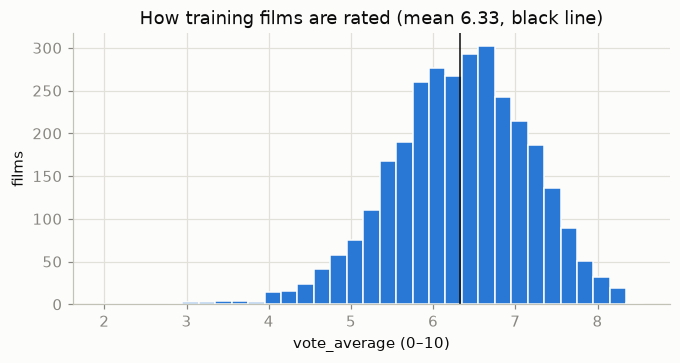

In [14]:
bins = np.arange(np.floor(y_train.min()) - 0.05, y_train.max() + 0.2, 0.2)  # ratings come in 0.1 steps: align bins to them
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(y_train, bins=bins, color=ACCENT, edgecolor=SURFACE, linewidth=1)
ax.axvline(y_train.mean(), color=INK, linewidth=1)
ax.set(title=f"How training films are rated (mean {y_train.mean():.2f}, black line)",
       xlabel="vote_average (0–10)", ylabel="films")
plt.show()

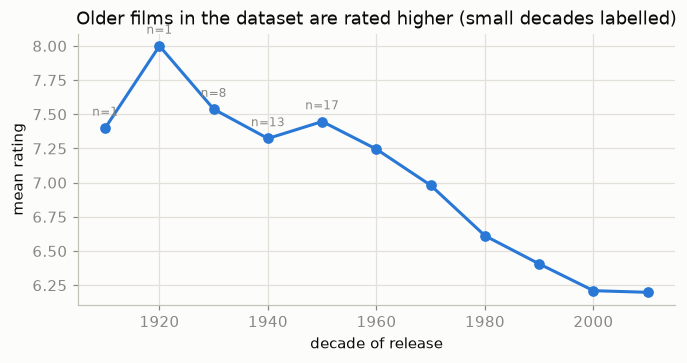

year,1910,1920,1930,1940,1950,1960,1970,1980,1990,2000,2010
mean,7.4,8.0,7.54,7.32,7.45,7.24,6.98,6.61,6.41,6.21,6.2
size,1.0,1.0,8.00,13.00,17.00,49.00,88.00,229.00,584.00,1568.00,527.0


In [15]:
decades = (X_train["year"] // 10 * 10).astype(int)
by_decade = y_train.groupby(decades).agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(by_decade.index, by_decade["mean"], color=ACCENT, linewidth=2, marker="o", markersize=6)
for decade, row in by_decade.query("size < 30").iterrows():  # label only the decades too small to trust
    ax.annotate(f"n={int(row['size'])}", (decade, row["mean"]), xytext=(0, 8), textcoords="offset points",
                ha="center", color=MUTED, fontsize=8)
ax.set(title="Older films in the dataset are rated higher (small decades labelled)",
       xlabel="decade of release", ylabel="mean rating")
plt.show()
by_decade.round(2).T

**Survivorship bias.** Old films are not better than new ones. The dataset is a *top 5,000* list, and only the acclaimed older films survived long enough to be in it, while it includes plenty of forgettable recent ones. A model given `year` can learn this pattern for the wrong reason, and a linear model will extend it into years it has never seen. Section 13 measures what that does to the test predictions.

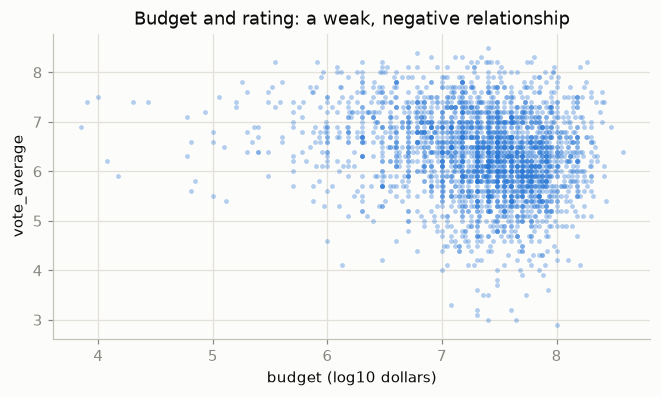

budget not disclosed: 11% of training films (50+ votes) | correlation with rating where known: -0.21


In [16]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.scatter(X_train["log_budget"], y_train, s=10, alpha=0.35, color=ACCENT, linewidths=0)
ax.set(title="Budget and rating: a weak, negative relationship", xlabel="budget (log10 dollars)", ylabel="vote_average")
plt.show()
print(f"budget not disclosed: {X_train['log_budget'].isna().mean():.0%} of training films (50+ votes) | "
      f"correlation with rating where known: {X_train['log_budget'].corr(y_train):.2f}")

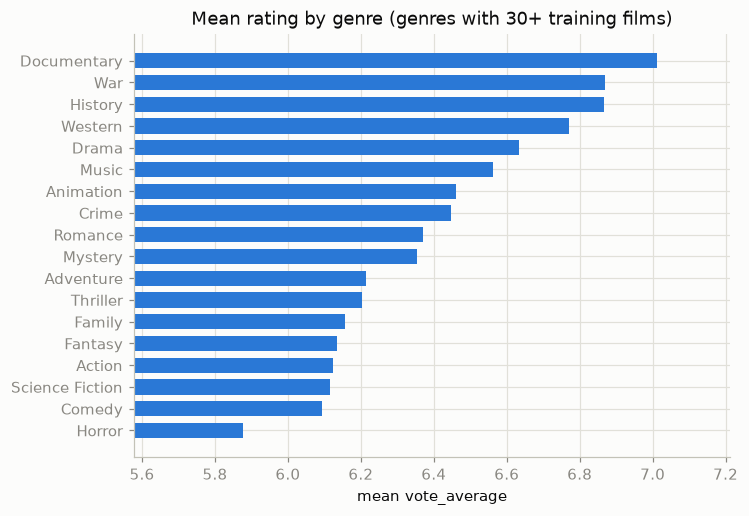

genre,Horror,Comedy,Science Fiction,Action,Fantasy,Family,Thriller,Adventure,Mystery,Romance,Crime,Animation,Music,Drama,Western,History,War,Documentary
mean,5.88,6.09,6.12,6.12,6.13,6.16,6.2,6.21,6.35,6.37,6.45,6.46,6.56,6.63,6.77,6.87,6.87,7.01
size,358.00,1143.00,389.00,811.00,334.00,362.00,924.0,580.00,273.00,582.00,519.00,163.00,108.00,1413.00,52.00,128.00,99.00,31.00


In [17]:
genre_rows = X_train.assign(rating=y_train, genre=X_train["genres"].str.split("|")).explode("genre")
by_genre = (genre_rows.query("genre != ''").groupby("genre")["rating"].agg(["mean", "size"])
            .query("size >= 30").sort_values("mean"))  # a mean of two films is not evidence
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(by_genre.index, by_genre["mean"], color=ACCENT, height=0.7)
ax.set_xlim(by_genre["mean"].min() - 0.3, by_genre["mean"].max() + 0.2)
ax.set(title="Mean rating by genre (genres with 30+ training films)", xlabel="mean vote_average")
plt.show()
by_genre.round(2).T

Exploding genres into rows is fine **here**: it's a copy made only to compute these per-genre averages. The model's data keeps one row per film.

## 8. One preprocessing pipeline for every model

A fair comparison gives every model identical inputs, and a leak-free one learns every preprocessing statistic (medians, scales, encodings) from the training folds only. A `ColumnTransformer` inside a `Pipeline` guarantees both: cross-validation refits the whole pipeline on each training fold.

| Step | What it does | Why |
|---|---|---|
| `SimpleImputer(median, add_indicator=True)` | fills missing budget/runtime, adds "was missing" flags | the sentinels from section 5 |
| `StandardScaler` | puts numbers on a common scale | distance- and penalty-based models (KNN, SVR, Ridge, Lasso) need it |
| `OneHotEncoder(min_frequency=20)` | one column per language; rare ones pooled into "infrequent" | 94% of films are in English; rare columns would be noise |
| `CountVectorizer(token_pattern=r"[^\|]+")` | splits `"Action\|Drama"` into one 0/1 column per genre | the multi-label feature, one row per film |
| `TargetEncoder` | replaces a director or actor with the average rating of their films, shrunk toward the overall mean when they have few (section 6's idea again) | over a thousand distinct names each; one-hot would add over a thousand mostly empty columns |

**Target encoding has a trap.** Encode a director by the average rating of their films, *including the film being encoded*, and that row partly sees its own answer. `TargetEncoder` avoids this with **cross-fitting**: during training, each row's encoding is computed from folds that exclude it.

In [18]:
def preprocessor(features: list[str]) -> ColumnTransformer:
    numeric = [f for f in ("log_budget", "runtime", "year", "month") if f in features]
    parts = [("numeric", make_pipeline(SimpleImputer(strategy="median", add_indicator=True), StandardScaler()), numeric)]
    if "original_language" in features:
        parts.append(("language", OneHotEncoder(min_frequency=20, handle_unknown="infrequent_if_exist",
                                                sparse_output=False), ["original_language"]))
    if "genres" in features:
        parts.append(("genres", CountVectorizer(token_pattern=r"[^|]+", lowercase=False, binary=True), "genres"))
    credit_columns = [f for f in ("director", "lead_cast") if f in features]
    if credit_columns:
        parts.append(("credits", TargetEncoder(cv=KFold(5, shuffle=True, random_state=SEED)), credit_columns))
    return ColumnTransformer(parts, sparse_threshold=0)

def pipeline(features: list[str], model) -> Pipeline:
    model_copy = clone(model)
    return Pipeline([("prep", preprocessor(features)), ("model", model_copy)])

encoded = preprocessor(CORE).fit(X_train[CORE], y_train)
print(f"{len(CORE)} input columns become {len(encoded.get_feature_names_out())} model columns")

6 input columns become 27 model columns


## 9. Twelve model families, compared fairly

**No Free Lunch** (Wolpert, 1996): no model is best on every problem, so trying many families is legitimate, and it is the best way to learn what each one assumes. The danger lies in *how* they are compared. Score twelve models on the test set, keep the best, and that best score is inflated by luck: the **winner's curse**, a form of the multiple-comparisons problem.

So the comparison happens **inside the training years** with **forward-chaining cross-validation** (`TimeSeriesSplit`). The training films are sorted by release date and cut into six blocks. Fold 1 trains on block 1 and validates on block 2; fold 2 trains on blocks 1–2 and validates on block 3; and so on. Every validation film is newer than everything its model trained on, exactly like the real task.

Every model starts from its library defaults, with one exception: Lasso's default penalty (`alpha=1`) zeroes every coefficient on standardised features, which turns it into the dummy. The models are listed simplest first; that order matters in section 10.

In [19]:
CV = TimeSeriesSplit(n_splits=5)
MAE = "neg_mean_absolute_error"

REGRESSORS = {  # simplest first: the one-standard-error rule reads this order
    "Mean (dummy)": DummyRegressor(),
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso (alpha=0.01)": Lasso(alpha=0.01),
    "Polynomial (degree 2)": make_pipeline(PolynomialFeatures(2), LinearRegression()),
    "Polynomial + Ridge": make_pipeline(PolynomialFeatures(2), Ridge()),
    "k-nearest neighbours": KNeighborsRegressor(),
    "Decision tree": DecisionTreeRegressor(random_state=SEED),
    "SVR": SVR(),
    "Random forest": RandomForestRegressor(random_state=SEED, n_jobs=-1),
    "Gradient boosting": GradientBoostingRegressor(random_state=SEED),
    "Hist gradient boosting": HistGradientBoostingRegressor(random_state=SEED),
}


def compare(models: dict, features: list[str], X: pd.DataFrame, y: pd.Series,
            scoring=MAE, lower_is_better: bool = True) -> pd.DataFrame:
    """Cross-validated score per model: mean, standard error, worst fold, fit time."""
    rows = {}
    for name, model in models.items():
        result = cross_validate(pipeline(features, model), X[features], y, cv=CV, scoring=scoring)
        scores = -result["test_score"] if lower_is_better else result["test_score"]
        rows[name] = {"mean": scores.mean(), "se": scores.std(ddof=1) / np.sqrt(len(scores)),
                      "worst fold": scores.max() if lower_is_better else scores.min(),
                      "fit seconds": result["fit_time"].mean()}
    return pd.DataFrame(rows).T


defaults = compare(REGRESSORS, CORE, X_train, y_train)
defaults.round(3)

,mean,se,worst fold,fit seconds
Mean (dummy),0.675,0.028,0.747,0.012
Linear,0.530,0.014,0.573,0.014
Ridge,0.530,0.014,0.572,0.012
Lasso (alpha=0.01),0.539,0.014,0.574,0.015
Polynomial (degree 2),0.636,0.073,0.921,0.052
Polynomial + Ridge,0.567,0.035,0.699,0.022
k-nearest neighbours,0.562,0.021,0.613,0.014
Decision tree,0.861,0.079,1.095,0.023
SVR,0.528,0.022,0.603,0.119
Random forest,0.549,0.021,0.619,0.118


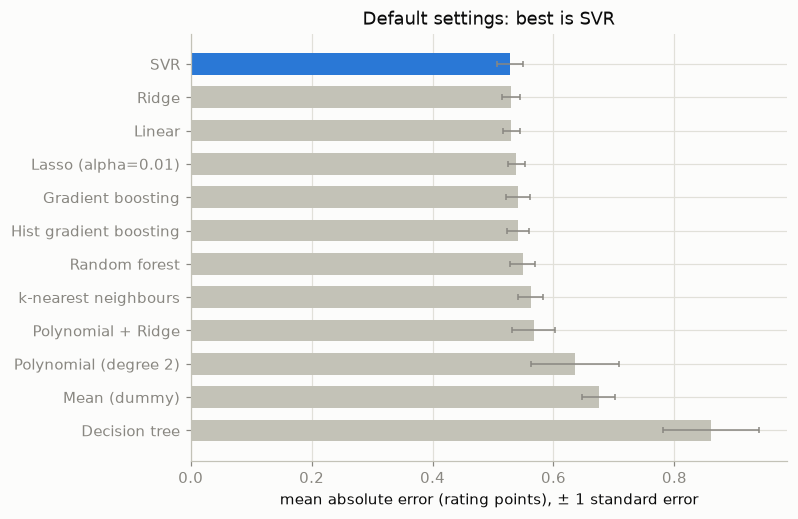

In [20]:
def plot_comparison(table: pd.DataFrame, highlight: str, xlabel: str, title: str, lower_is_better: bool = True) -> None:
    order = table.sort_values("mean", ascending=not lower_is_better)  # best ends up on top
    colors = [ACCENT if name == highlight else OTHER for name in order.index]
    fig, ax = plt.subplots(figsize=(7, 0.32 * len(order) + 1.2))
    ax.barh(order.index, order["mean"], xerr=order["se"], color=colors, height=0.65,
            error_kw={"ecolor": MUTED, "elinewidth": 1, "capsize": 2})
    ax.set(title=title, xlabel=xlabel)
    plt.show()


best_default = defaults["mean"].idxmin()
plot_comparison(defaults, best_default, "mean absolute error (rating points), ± 1 standard error",
                f"Default settings: best is {best_default}")

### What each family assumes, and what happened here

| Family | Assumes | Wins when | Costs | Here |
|---|---|---|---|---|
| Mean (dummy) | nothing | never: it's the floor every model must beat | nothing | the reference point |
| Linear / Ridge | the rating is a weighted sum of inputs | relationships are roughly additive; few rows | trivial | about 0.14 below the dummy, and hard to beat |
| Lasso | as linear, but many weights are exactly zero | many irrelevant inputs | trivial | slightly worse: there are few inputs to discard |
| Polynomial (degree 2) | pairwise interactions matter | interactions are real *and* rows are plentiful | columns grow with the square of the inputs | its worst fold shows overfitting: about 400 columns, learned from as few as 500 films in the early folds |
| Polynomial + Ridge | as above, with a penalty | same, with the penalty taming the variance | the penalty strength needs tuning | regularisation recovers most of the loss |
| k-nearest neighbours | similar films have similar ratings | low-dimensional, dense data | slow predictions; sensitive to scaling | worse: with 27 dimensions "nearest" gets weak (the *curse of dimensionality*) |
| Decision tree | the answer is a set of if-then rules | strong thresholds; interpretability matters | unstable; overfits when grown fully | the worst real model: an unlimited tree memorises its training films |
| SVR | a smooth function fits within a margin | medium-sized data, smooth relationships | training time grows with the square of the rows or faster | competitive, but only by a margin within noise |
| Random forest | many decorrelated trees average out | complex interactions; little tuning | memory and time with many trees | averaging fixes the single tree's overfitting, but not past linear |
| Gradient boosting / Hist GB | each tree fixes the previous trees' errors | large tabular data with interactions (Grinsztajn et al., 2022) | tuning, time | no better than linear on about 2,500 rows with mostly additive signal |

Run the notebook and check each "Here" claim against the table above.

## 10. Tune the shortlist, then choose with the one-standard-error rule

Defaults can be unfair to models that need tuning. So we give the **four best families** their best shot with a small grid search, still inside the training years. Then we choose.

**The one-standard-error rule** (Breiman et al., 1984; Hastie, Tibshirani & Friedman, *Elements of Statistical Learning*, §7.10) says: find the best average score, then choose the **simplest** model whose score is within one standard error of it. Differences smaller than the noise in our own measurement are not evidence, so we don't pay for complexity they don't justify. The standard error here treats the five folds as independent measurements. They aren't (their training sets overlap), so it is a rough yardstick, but it is the standard one for this rule.

In [21]:
GRIDS = {  # small grids: the point is a fair chance, not an exhaustive search
    "Ridge": {"model__alpha": [0.1, 1, 10, 100]},
    "Lasso (alpha=0.01)": {"model__alpha": [0.001, 0.003, 0.01, 0.03]},
    "Polynomial + Ridge": {"model__ridge__alpha": [1, 10, 100, 1000]},
    "k-nearest neighbours": {"model__n_neighbors": [10, 25, 50, 100]},
    "Decision tree": {"model__max_depth": [3, 5, 8], "model__min_samples_leaf": [5, 20]},
    "SVR": {"model__C": [0.3, 1, 3], "model__epsilon": [0.1, 0.3]},
    "Random forest": {"model__min_samples_leaf": [5, 20], "model__max_features": [0.3, 1.0]},
    "Gradient boosting": {"model__learning_rate": [0.03, 0.1], "model__max_depth": [2, 3], "model__n_estimators": [100, 300]},
    "Hist gradient boosting": {"model__learning_rate": [0.03, 0.1], "model__max_leaf_nodes": [7, 31],
                               "model__l2_regularization": [0, 1]},
}


def one_standard_error(table: pd.DataFrame, lower_is_better: bool = True) -> str:
    """Simplest model (table order) whose mean score is within one standard error of the best."""
    best = table["mean"].idxmin() if lower_is_better else table["mean"].idxmax()
    margin = table.loc[best, "se"]
    within = (table["mean"] <= table.loc[best, "mean"] + margin) if lower_is_better \
        else (table["mean"] >= table.loc[best, "mean"] - margin)
    return within.idxmax()  # first True in simplest-first order


shortlist = defaults.drop(index="Mean (dummy)").nsmallest(4, "mean").index
tuned_models = dict(REGRESSORS)
for name in shortlist:
    if name in GRIDS:
        search = GridSearchCV(pipeline(CORE, REGRESSORS[name]), GRIDS[name], cv=CV, scoring=MAE).fit(X_train[CORE], y_train)
        tuned_models[name] = search.best_estimator_.named_steps["model"]
        print(f"{name:24} best settings: {search.best_params_}")

contenders = {name: tuned_models[name] for name in REGRESSORS if name in shortlist}
tuned = compare(contenders, CORE, X_train, y_train)
chosen = one_standard_error(tuned)
tuned.round(3)

SVR                      best settings: {'model__C': 1, 'model__epsilon': 0.3}
Ridge                    best settings: {'model__alpha': 1}
Lasso (alpha=0.01)       best settings: {'model__alpha': 0.001}


,mean,se,worst fold,fit seconds
Linear,0.530,0.014,0.573,0.012
Ridge,0.530,0.014,0.572,0.013
Lasso (alpha=0.01),0.530,0.014,0.572,0.012
SVR,0.517,0.020,0.575,0.090


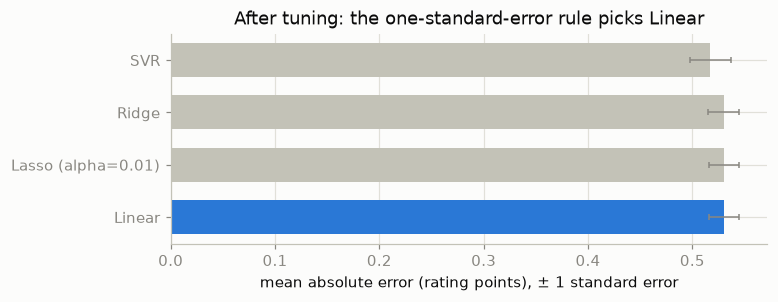

best average: SVR (0.517 ± 0.020) | chosen: Linear (0.530)


In [22]:
plot_comparison(tuned, chosen, "mean absolute error (rating points), ± 1 standard error",
                f"After tuning: the one-standard-error rule picks {chosen}")
best = tuned["mean"].idxmin()
print(f"best average: {best} ({tuned.loc[best, 'mean']:.3f} ± {tuned.loc[best, 'se']:.3f}) | "
      f"chosen: {chosen} ({tuned.loc[chosen, 'mean']:.3f})")

### Do credits earn their place?

Director and lead actor were the inputs with the most promise and the most risk (section 8's trap, and *cold start*: many new films bring a director the model has never seen). The same rule decides: credits stay only if they improve on core features by more than the noise.

In [23]:
model = tuned_models[chosen]
stages = {"core": CORE, "core + credits": CORE + CREDITS}
stage_table = pd.DataFrame({
    stage: compare({stage: model}, features, X_train, y_train).iloc[0] for stage, features in stages.items()
}).T
FEATURES = stages[one_standard_error(stage_table)]
print(f"features used by the final model: {FEATURES}")
stage_table.round(3)

features used by the final model: ['log_budget', 'runtime', 'year', 'month', 'original_language', 'genres']


,mean,se,worst fold,fit seconds
core,0.530,0.014,0.573,0.02
core + credits,0.518,0.019,0.576,0.03


## 11. The test set, used once

Every decision is now made. We fit the chosen pipeline on all training films and score it on the 2013–2016 films, **once**.

A single number hides its own uncertainty. The **bootstrap** estimates it: resample the test films with replacement thousands of times, recompute the error each time, and read off the middle 95% of the results. We bootstrap the *improvement over the dummy* the same way, on the same resampled films each time (a paired comparison), which answers the question that matters: does the model really beat guessing the average?

In [24]:
final = pipeline(FEATURES, model).fit(X_train[FEATURES], y_train)
baseline = pipeline(FEATURES, DummyRegressor()).fit(X_train[FEATURES], y_train)
predicted, guessed = final.predict(X_test[FEATURES]), baseline.predict(X_test[FEATURES])
errors, dummy_errors = np.abs(y_test.to_numpy() - predicted), np.abs(y_test.to_numpy() - guessed)

rng = np.random.default_rng(SEED)
samples = rng.integers(0, len(errors), size=(5000, len(errors)))
mae_ci = np.percentile(errors[samples].mean(axis=1), [2.5, 97.5])
gain_ci = np.percentile((dummy_errors[samples] - errors[samples]).mean(axis=1), [2.5, 97.5])

print(f"test films: {len(errors)}")
print(f"{chosen}: MAE {errors.mean():.3f}  (95% CI {mae_ci[0]:.3f}–{mae_ci[1]:.3f})")
print(f"dummy: MAE {dummy_errors.mean():.3f}")
print(f"improvement over the dummy: {dummy_errors.mean() - errors.mean():.3f}  (95% CI {gain_ci[0]:.3f}–{gain_ci[1]:.3f})")

test films: 567
Linear: MAE 0.619  (95% CI 0.580–0.659)
dummy: MAE 0.703
improvement over the dummy: 0.084  (95% CI 0.054–0.115)


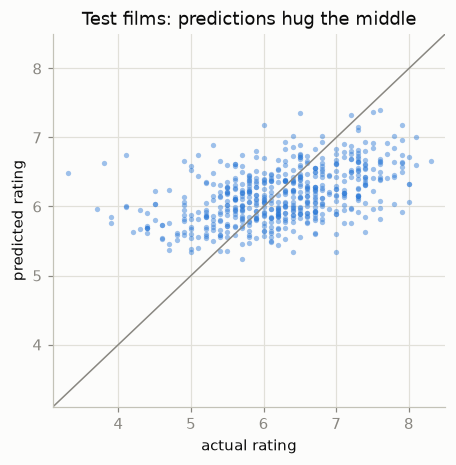

In [25]:
fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(y_test, predicted, s=12, alpha=0.45, color=ACCENT, linewidths=0)
limits = [min(y_test.min(), predicted.min()) - 0.2, max(y_test.max(), predicted.max()) + 0.2]
ax.plot(limits, limits, color=MUTED, linewidth=1)
ax.set(xlim=limits, ylim=limits, xlabel="actual rating", ylabel="predicted rating",
       title="Test films: predictions hug the middle")
plt.show()

Predictions spread less than the actual ratings (the diagnostic below prints both spreads). That is what a model with modest signal *should* do: with little to go on, it hedges toward the average rather than inventing confident extremes. Points far from the grey diagonal are films the pre-release data could not foresee.

### Why is the test error higher than cross-validation?

Cross-validation estimated about 0.53; the test films came in clearly worse. When a test score disappoints, the tempting move is to go back and change the model. **Don't.** A change chosen by looking at the test set makes the test set a tuning set, and the score stops being an honest estimate. Diagnose instead: compare the two periods.

In [26]:
residuals = y_test.to_numpy() - predicted
print(f"mean residual on test: {residuals.mean():+.3f} | spread of predictions {predicted.std():.2f} "
      f"vs actual ratings {y_test.std():.2f}")
pd.DataFrame({
    "training films (before 2013)": [y_train.mean(), y_train.std(), X_train["log_budget"].corr(y_train),
                                     X_train["runtime"].corr(y_train)],
    "test films (2013 to 2016)": [y_test.mean(), y_test.std(), X_test["log_budget"].corr(y_test),
                                  X_test["runtime"].corr(y_test)],
}, index=["mean rating", "rating spread (sd)", "corr(log budget, rating)", "corr(runtime, rating)"]).round(3)

mean residual on test: +0.069 | spread of predictions 0.39 vs actual ratings 0.87


,training films (before 2013),test films (2013 to 2016)
mean rating,6.329,6.232
rating spread (sd),0.835,0.873
"corr(log budget, rating)",-0.208,0.166
"corr(runtime, rating)",0.399,0.424


**Concept drift.** The relationship between budget and rating **changed sign** between the periods. Before 2013, bigger budgets went with slightly *lower* ratings; from 2013, with slightly *higher* ones. The franchise era is one plausible reason. Runtime's relationship stayed stable. The model learned the old budget pattern, and the world moved.

Cross-validation could not see this, because every fold predates 2013. Forward chaining assumes the near future resembles the recent past; when that breaks, only **monitoring** a deployed model catches it, and **retraining** fixes it. That's what drift detection in an MLOps pipeline is for.

Two more reasons the test set is harder. Its ratings spread wider, so even the dummy does worse. And the newest films had less time to collect 50 votes, so 2016 contributes 82 films, about half as many as 2013, and only ones that drew attention quickly.

Would dropping budget have helped? Perhaps, but this test set can no longer tell us honestly. Answering it would take a fresh test period (exercise 4).

## 12. Rating bands: regression versus a direct classifier

The brief also asked for rating classes. The first version's thresholds (above 8 = High) left **five** "High" films out of 4,803. Here the bands are the **thirds** of the training ratings (Low, Mid, High), so the bands are about equally common in training (ratings come in steps of 0.1, so ties at the cut-offs keep them from being exact thirds).

There are two ways to predict a band:

- **Regression → bands:** predict the rating, then apply the thresholds. No extra model, and it uses the full rating rather than three bins.
- **A direct classifier**, trained on the bands themselves, so it learns the band boundaries directly.

Which wins is an empirical question, so we compare both with forward chaining, scored by **macro-F1**: the F1 score per band, averaged, so every band counts equally. Plain accuracy can look good while a model ignores a whole band.

One subtlety: the cut-offs come from all training films. Every band model, regression → bands included, uses the same fixed cut-offs, so the comparison is like for like. But inside cross-validation the early folds are labelled with cut-offs set partly by later films: fold 1's own films would put them about 0.5 higher, because older films rate higher (section 7).

In [27]:
cuts = np.quantile(y_train, [1 / 3, 2 / 3])
BANDS = np.array(["Low", "Mid", "High"])


def to_band(ratings) -> np.ndarray:
    return BANDS[np.digitize(ratings, cuts)]


band_train, band_test = to_band(y_train), to_band(y_test)
print(f"band thresholds from training films: Low < {cuts[0]:.2f} ≤ Mid < {cuts[1]:.2f} ≤ High")

CLASSIFIERS = {  # simplest first
    "Most frequent (dummy)": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": LogisticRegression(max_iter=2000),
    "k-nearest neighbours": KNeighborsClassifier(n_neighbors=25),
    "Decision tree": DecisionTreeClassifier(max_depth=5, random_state=SEED),
    "SVC": SVC(),
    "Random forest": RandomForestClassifier(min_samples_leaf=5, random_state=SEED, n_jobs=-1),
    "Hist gradient boosting": HistGradientBoostingClassifier(random_state=SEED),
}
MACRO_F1 = make_scorer(f1_score, average="macro", zero_division=0)  # the dummy never predicts two bands
classifier_table = compare(CLASSIFIERS, FEATURES, X_train, pd.Series(band_train, index=X_train.index),
                           scoring=MACRO_F1, lower_is_better=False)

fold_scores, regression_bands = [], []  # regression -> bands, scored on the same forward-chaining folds
for fit_rows, check_rows in CV.split(X_train):
    regressor = pipeline(FEATURES, model).fit(X_train[FEATURES].iloc[fit_rows], y_train.iloc[fit_rows])
    regression_bands.append(to_band(regressor.predict(X_train[FEATURES].iloc[check_rows])))
    fold_scores.append(f1_score(band_train[check_rows], regression_bands[-1], average="macro"))
regression_row = pd.DataFrame({"mean": np.mean(fold_scores), "se": np.std(fold_scores, ddof=1) / np.sqrt(len(fold_scores)),
                               "worst fold": np.min(fold_scores), "fit seconds": np.nan}, index=["Regression → bands"])
bands_table = pd.concat([classifier_table.iloc[:1], regression_row, classifier_table.iloc[1:]])  # no new model: second simplest
band_choice = one_standard_error(bands_table, lower_is_better=False)
bands_table.round(3)

band thresholds from training films: Low < 6.00 ≤ Mid < 6.70 ≤ High


,mean,se,worst fold,fit seconds
Most frequent (dummy),0.161,0.006,0.145,0.014
Regression → bands,0.481,0.018,0.424,NaN
Logistic regression,0.513,0.013,0.481,0.038
k-nearest neighbours,0.476,0.027,0.369,0.015
Decision tree,0.467,0.016,0.409,0.020
SVC,0.490,0.025,0.393,0.105
Random forest,0.497,0.032,0.372,0.179
Hist gradient boosting,0.488,0.009,0.465,0.452


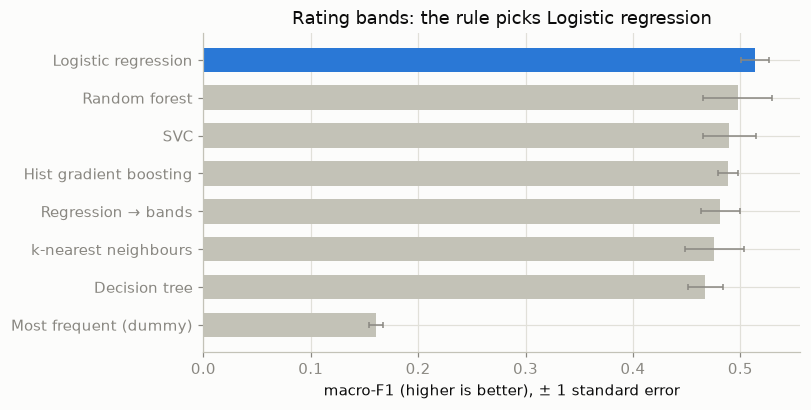

,actual,regression → bands
Low,0.35,0.26
Mid,0.34,0.58
High,0.32,0.16


In [28]:
plot_comparison(bands_table, band_choice, "macro-F1 (higher is better), ± 1 standard error",
                f"Rating bands: the rule picks {band_choice}", lower_is_better=False)
checked = np.concatenate([band_train[check_rows] for _, check_rows in CV.split(X_train)])
pd.DataFrame({"actual": pd.Series(checked).value_counts(normalize=True),
              "regression → bands": pd.Series(np.concatenate(regression_bands)).value_counts(normalize=True)
              }).reindex(BANDS).round(2)

The table shows why the regression route loses here. Its predictions are compressed toward the mean (section 11), so they rarely cross the outer thresholds, and too many films come out **Mid**. A classifier is trained to separate the bands, so it predicts all three. When a regression's predictions are compressed, thresholding them under-predicts the extremes.

Logistic regression on test films: macro-F1 0.482, balanced accuracy 0.482  (chance = 0.333)


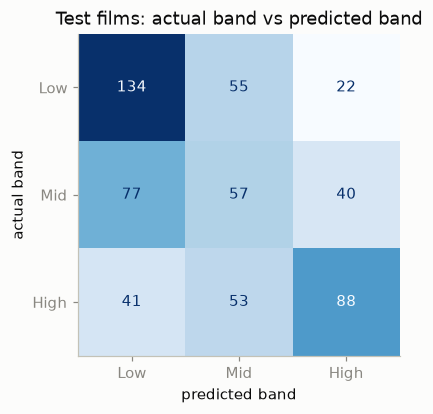

predicted,Low,Mid,High
actual,,,
Low,134,55,22
Mid,77,57,40
High,41,53,88


In [29]:
band_model = (final if band_choice == "Regression → bands"
              else pipeline(FEATURES, CLASSIFIERS[band_choice]).fit(X_train[FEATURES], band_train))
band_predicted = (to_band(band_model.predict(X_test[FEATURES])) if band_choice == "Regression → bands"
                  else band_model.predict(X_test[FEATURES]))
print(f"{band_choice} on test films: macro-F1 {f1_score(band_test, band_predicted, average='macro'):.3f}, "
      f"balanced accuracy {balanced_accuracy_score(band_test, band_predicted):.3f}  (chance = 0.333)")
fig, ax = plt.subplots(figsize=(4.4, 3.8))
ConfusionMatrixDisplay.from_predictions(band_test, band_predicted, labels=BANDS, cmap="Blues", colorbar=False, ax=ax)
ax.grid(False)
ax.set(title="Test films: actual band vs predicted band", xlabel="predicted band", ylabel="actual band")
plt.show()
pd.crosstab(pd.Series(band_test, name="actual"), pd.Series(band_predicted, name="predicted")).reindex(index=BANDS, columns=BANDS)

Read the confusion matrix by row: each row is an actual band, each column the predicted one. The diagonal holds the hits. Low films are recognised best. **Mid is the hardest band**: Mid films are spread across all three predictions, because the middle of a distribution borders both neighbours. The far corners are worth a look too: some High films are called Low. Macro-F1 well above chance (0.33) but far below 1 is what *real but limited* signal looks like, and it is the honest replacement for the first version's 1.0000.

## 13. What drives the predictions

**Permutation importance** asks: if we shuffle one input column on the test films, breaking its link to the rating, how much worse does the model get? A large drop means the model relies on that column. Measuring it on test data (not training data) shows what generalises rather than what was memorised. One caveat: when two inputs carry overlapping information, shuffling one lets the other compensate, so both can look less important than they are.

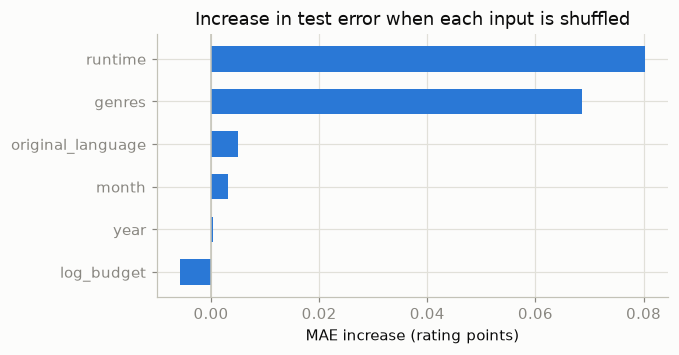

runtime              0.0803
genres               0.0686
original_language    0.0049
month                0.0032
year                 0.0003
log_budget          -0.0057
dtype: float64

In [30]:
importance = permutation_importance(final, X_test[FEATURES], y_test, scoring=MAE, n_repeats=20, random_state=SEED)
ranked_inputs = pd.Series(importance.importances_mean, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(6, 0.35 * len(FEATURES) + 1))
ax.barh(ranked_inputs.index, ranked_inputs.values, color=ACCENT, height=0.6)
ax.axvline(0, color=BASE, linewidth=1)
ax.set(title="Increase in test error when each input is shuffled", xlabel="MAE increase (rating points)")
plt.show()
ranked_inputs.sort_values(ascending=False).round(4)

A **negative** importance means the model does *better* when that column is scrambled: what it learned from that column is now actively misleading. That is the budget drift from section 11, seen from the model's side.

**Near zero is not the same as unused.** The model learned the survivorship trend from section 7 (older films rated higher) and extends that line into 2013–2016, years it never saw: **extrapolation**. That moves every test prediction by about the same amount. Shuffling `year` among test films that all come from those four years barely changes anything, so permutation importance cannot see a shift shared by all of them. The next cell measures it directly, by giving every test film the training films' average year.

In [31]:
average_year = final.predict(X_test[FEATURES].assign(year=X_train["year"].mean()))
print(f"year moves test predictions by {np.mean(predicted - average_year):+.2f} on average")

year moves test predictions by -0.15 on average


## 14. Save the model safely, and use it

`pickle` and `joblib` files can **run arbitrary code when loaded**, which is a real attack route for shared models. **skops** stores a model as data, not code. When loading, it lists every type it would create that it doesn't already trust, and loads nothing until you confirm them. Below we accept only types from scikit-learn, NumPy or Python's built-ins, and fail otherwise.

Then one more check: the loaded model must reproduce the test predictions from section 11 exactly. A saved model that answers differently from the one you evaluated is a silent and common bug: the scores you report would describe a model nobody can use.

In [32]:
MODEL_PATH = Path("models/tmdb_rating_model.skops")
MODEL_PATH.parent.mkdir(exist_ok=True)
sio.dump(final, MODEL_PATH)

untrusted = sio.get_untrusted_types(file=MODEL_PATH)
assert all(name.split(".")[0] in {"sklearn", "numpy", "builtins"} for name in untrusted), untrusted
loaded = sio.load(MODEL_PATH, trusted=untrusted)
assert np.allclose(loaded.predict(X_test[FEATURES]), predicted), "the saved model does not reproduce the test predictions"
print(f"saved {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1024:.0f} KB); types reviewed: {untrusted}")

saved models\tmdb_rating_model.skops (200 KB); types reviewed: ['numpy.dtype']


In [33]:
upcoming = pd.DataFrame([{
    "log_budget": np.log10(150_000_000), "runtime": 128, "year": 2026, "month": 12, "original_language": "en",
    "genres": "Science Fiction|Adventure", "director": "Denis Villeneuve", "lead_cast": "Timothée Chalamet",
}])
print(f"predicted rating: {loaded.predict(upcoming[FEATURES])[0]:.2f}  "
      f"(band: {to_band(loaded.predict(upcoming[FEATURES]))[0]})")
print(f"the same film dated 2016: {loaded.predict(upcoming[FEATURES].assign(year=2016))[0]:.2f}")

predicted rating: 6.12  (band: Mid)
the same film dated 2016: 6.23


Change the inputs and re-run to see how the model responds. The model reads only the columns in `FEATURES`, the ones section 10 kept. Director and cast are in the example so that it still works if you change the eligibility table, or if the rule ever keeps the credit features. In that case, a director the model never saw falls back to the overall average: the cold-start problem.

Notice the year. 2026 lies far beyond the training films, which end in 2012, so the year trend from section 13 lowers this prediction: compare it with the same film dated 2016.

## 15. Common pitfalls: what the first version got wrong

Each mistake below was in the published first version, and each has a check that catches it.

| Pitfall | What happened | How to catch it |
|---|---|---|
| Target leakage | Features included `vote_average` and `vote_count`, the target's own inputs: error ≈ 0.0001 | Section 4's eligibility table; the guard in section 7 |
| Label as a feature | The classifier received `rating_class`: accuracy 1.0000 | Same guard: no target-derived column among the inputs |
| Duplicates across the split | Exploding genres put the same film in train and test (measured below) | Guard: no film id in both sets; one row per film |
| Test-set reuse | Nine regressors and five classifiers tuned and ranked on the test set | Compare on training folds; test once (sections 9–11) |
| Character loop | `for genre in row['genres']` iterated the *letters* of each genre after the explode | Vectorised `groupby`; look at intermediate tables |
| Sentinels and unit errors | 22% of budgets were 0, and some were \$1–\$100 (entered in millions); all used as real numbers | `describe()` and a scatter plot: values that are impossible for the domain |
| Environment paths | Read from `/content/` (Colab only) | Keep the data in the repository and read it by a relative path |
| Removed API | `OneHotEncoder(sparse=False)` crashes on scikit-learn ≥ 1.4 | Pinned versions (`uv.lock`); re-run the notebook from a clean kernel |
| Mismatched plots | Re-tuned every model with `cv=5` just to plot, so the plots showed different models from the scores (`cv=3`) | Plot the models you scored |

Two of these are worth seeing with your own eyes.

In [34]:
w_m = films.loc[train_idx, "vote_count"].quantile(0.8)
w_C = y_train.mean()
leaky_target = bayesian_average(films.loc[train_idx, "vote_count"], y_train, w_m, w_C)
leaky_inputs = X_train[CORE].assign(vote_average=y_train, vote_count=films.loc[train_idx, "vote_count"])
leaky_pipe = Pipeline([("prep", ColumnTransformer([("passthrough", "passthrough", ["vote_average", "vote_count"])])),
                       ("model", HistGradientBoostingRegressor(random_state=SEED))])
leaky = -cross_validate(leaky_pipe, leaky_inputs, leaky_target, cv=CV, scoring=MAE)["test_score"].mean()
honest = -cross_validate(pipeline(CORE, HistGradientBoostingRegressor(random_state=SEED)), X_train[CORE],
                         leaky_target, cv=CV, scoring=MAE)["test_score"].mean()
print(f"predicting the weighted rating WITH its own inputs: MAE {leaky:.4f}   <- too good to be true")
print(f"predicting it from pre-release features only:      MAE {honest:.4f}")

predicting the weighted rating WITH its own inputs: MAE 0.0145   <- too good to be true
predicting it from pre-release features only:      MAE 0.2006


In [35]:
genre_lists = films["genres"].map(lambda text: [item["name"] for item in json.loads(text)])
exploded = films[["id", "genres"]].assign(genre=genre_lists).explode("genre")
v1_train, v1_test = train_test_split(exploded, test_size=0.2, random_state=42)
print(f"first version's split: {v1_test['id'].isin(v1_train['id']).mean():.0%} of test rows were films also in training")

first version's split: 86% of test rows were films also in training


## What the results mean

- **The chosen model.** SVR had the best tuned cross-validation score (0.517 ± 0.020), but plain linear regression (0.530) sits within one standard error of it. The gap is indistinguishable from noise, so the simpler model was kept.
- **The size of the error.** On films released from 2013 onwards, the model misses by 0.62 rating points on average, against 0.70 for always predicting the training mean. The gain is real (its confidence interval excludes zero) but small: the model captures broad tendencies, not individual hits.
- **What drives it.** Runtime and genre do most of the work of telling films apart; language and release month add a little. `year` barely tells test films apart, yet the survivorship trend it learned lowers every test prediction by about 0.15, a shift permutation importance cannot see.
- **Budget.** Its importance is negative on test because its relationship with rating changed sign after 2012: concept drift, which the training years could not reveal.
- **What to try next.** The synopsis (`overview`) is known before release and describes a film far more richly than its genre labels. It is the natural next feature (exercise 1).

## 16. Exercises

1. **Text features.** `overview` (the synopsis) is allowed. Encode it with TF-IDF or sentence embeddings, add it to the pipeline, and let the one-standard-error rule decide whether it earns its place.
2. **Weights instead of a threshold.** Use every film with at least 10 votes, and pass `sample_weight` proportional to `vote_count / (vote_count + m)`. Does it beat the 50-vote filter?
3. **Real dollars.** Budgets are nominal, so a 1990 budget isn't comparable to a 2012 one. Adjust them with a consumer price index and see whether `log_budget` becomes more useful.
4. **Stability and drift.** Move `TEST_FROM` to 2011 and keep 2013–2016 untouched as a fresh test. Does the same family win? Does dropping `log_budget` help on the new validation period? A choice that flips with the split year was within noise all along.
5. **The unrated tail.** Predict films with fewer than 50 votes. What bias would you expect, given that the model only learned from films that drew enough attention to be rated?

## References

- Kapoor, S. & Narayanan, A. (2023). *Leakage and the reproducibility crisis in machine-learning-based science.* Patterns 4(9).
- Wolpert, D. H. (1996). *The lack of a priori distinctions between learning algorithms.* Neural Computation 8(7).
- Breiman, L., Friedman, J., Olshen, R. & Stone, C. (1984). *Classification and Regression Trees.* (the one-standard-error rule)
- Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*, 2nd ed., §7.10.
- Grinsztajn, L., Oyallon, E. & Varoquaux, G. (2022). *Why do tree-based models still outperform deep learning on tabular data?* NeurIPS Datasets and Benchmarks.
- Micci-Barreca, D. (2001). *A preprocessing scheme for high-cardinality categorical attributes.* SIGKDD Explorations 3(1). (target encoding)
- [scikit-learn: `TargetEncoder` and cross-fitting](https://scikit-learn.org/stable/modules/preprocessing.html#target-encoder)
- [TMDB API terms of use](https://www.themoviedb.org/api-terms-of-use) · [TMDB 5000 dataset on Kaggle](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata)